In [6]:
from calc_script import create_stats_df
from calc_script import create_plant_summary
from calc_script import create_a_summary_plot
from IPython.display import display

In [7]:
START_DATE = '2025-10-20'
END_DATE = '2026-04-20'
# START_DATE = '2025-04-20'
# END_DATE = '2025-07-20'
GET_ALL_DATES_FROM_MB51 = False

PRODUCTION_PLANT = '2101'

# 95% -> k = 1.96 (most common choice)
# 96% -> k = 2,05 (best choice)
# 99% -> k = 2.33
K_PARAMETER = 2.05


In [8]:
exchange_rates = {
    'EUR': 1.0,
    'PLN': 0.23,  # Przykład: 1 PLN = 0.23 EUR
    'CZK': 0.04   # Przykład: 1 CZK = 0.04 EUR
}

mb51_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_Consumption.XLSX"
zsbe_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_items_and_parameters.XLSX"

output_directory = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\output"

In [9]:
stats_df = create_stats_df(mb51_path, zsbe_path, PRODUCTION_PLANT, GET_ALL_DATES_FROM_MB51, START_DATE, END_DATE, K_PARAMETER, exchange_rates)

Dates for calculations DatetimeIndex(['2025-10-20', '2025-10-21', '2025-10-22', '2025-10-23',
               '2025-10-24', '2025-10-27', '2025-10-28', '2025-10-29',
               '2025-10-30', '2025-10-31',
               ...
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-20'],
              dtype='datetime64[ns]', length=131, freq='B')


In [10]:
stats_df[['plant', 'material', 'material_description', 'lead_time',
                         'daily_avg_consumption', 'new_safety_stock', 'new_ss_range', 'new_safety_stock_value', 'reorder_point', 'ROP_value', 'safety_stock_in_SAP', 'ss_diff']].head(10)

,plant,material,material_description,lead_time,daily_avg_consumption,new_safety_stock,safety_stock_value,reorder_point,ROP_value,safety_stock_in_SAP,ss_diff,new_ss_range
0,2101,808965,R79_ 074/118 K200,2,12.2672,63,12591.95,88,17588.76,200,-137,5.14
1,3701,808965,R79_ 074/118 K200,7,11.1298,145,33627.12,223,51716.20,252,-107,13.03
2,2101,839134,R49_ 074/118 K200,2,10.3130,45,8882.06,66,13027.02,150,-105,4.36
3,2101,808966,R79_ 074/140 K200,2,8.9466,48,10391.29,66,14288.02,200,-152,5.37
4,2101,839135,R49_ 074/140 K200,2,6.5115,28,6018.63,42,9027.95,96,-68,4.30
5,3701,808966,R79_ 074/140 K200,3,4.4809,37,9298.62,51,12817.01,100,-63,8.26
6,1201,497669,R79T 114/118 K100L1,4,2.1832,14,2753.80,23,4524.10,50,-36,6.41
7,3701,808964,R79_ 074/098 K200,4,1.8473,15,3072.80,23,4711.63,35,-20,8.12
8,3701,2002538,R79C 074/118 K200,5,1.8321,22,5868.80,32,8536.44,19,3,12.01
9,1201,497661,R79T 078/098 K100L1,4,1.7023,13,2156.57,20,3317.80,40,-27,7.64


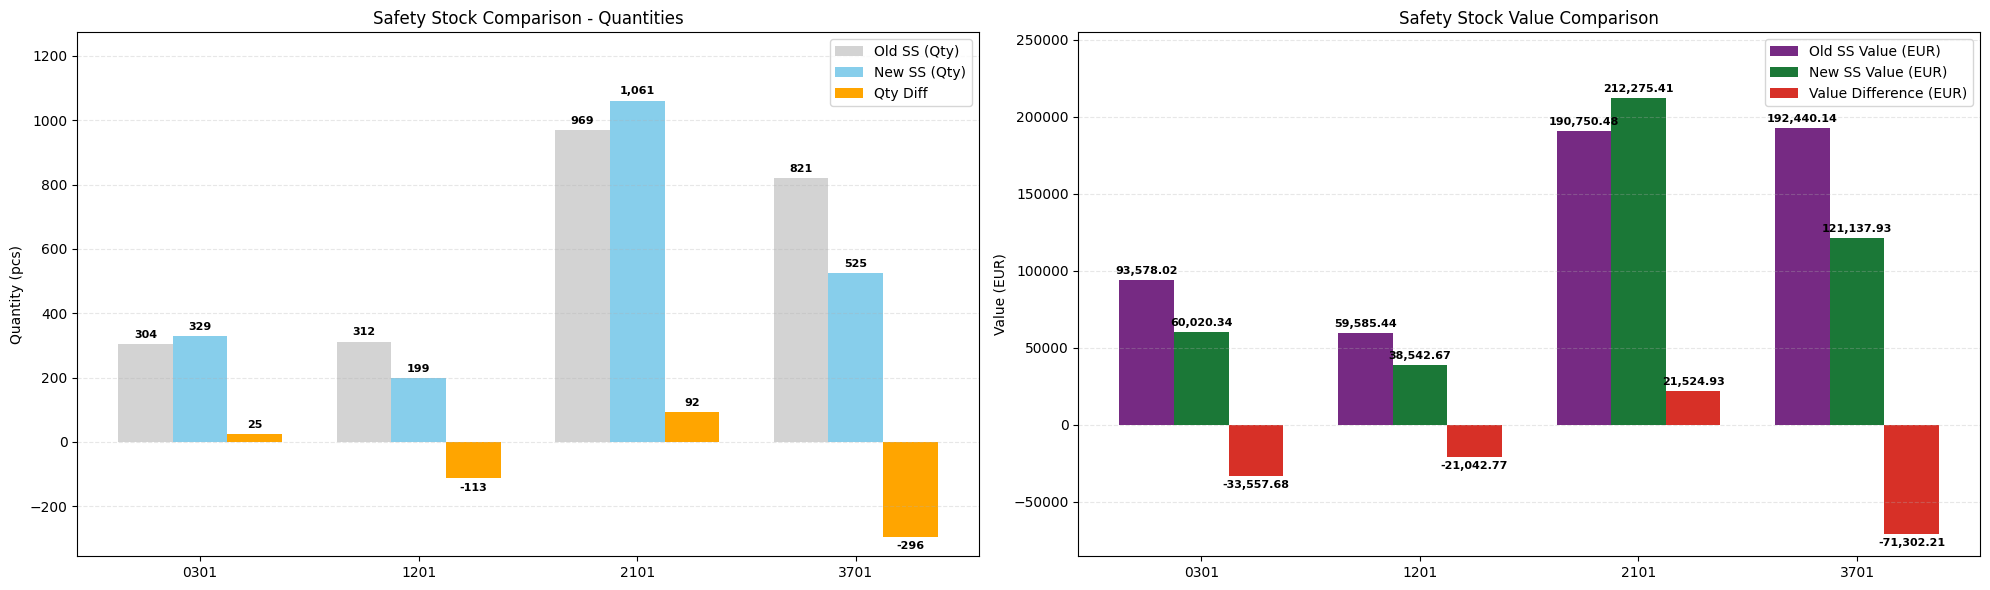

In [11]:
plant_summary = create_plant_summary(stats_df)
fig = create_a_summary_plot(plant_summary)
display(fig)

In [12]:
stats_df.to_excel(f"{output_directory}\stats_df_past_6_months_last_year.xlsx")